# Датасет - Виды ириса
### Структура данных

| Признак | Описание |
|---------|----------|
|Id | Айди |
|SepalLengthCm| Длина чашелистика|
|SepalWidthCm| Ширина чашелистика|
|PetalLengthCm| Длина лепестка|
|PetalWidthCm| Ширина лепестка|
|Species| Вид|

Датасет состоит из 6 колонок (6 признаков) и 150 строк

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from IPython.display import display

# Настройка отображения
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
sns.set(font_scale=1.2)

# 1. Загрузка данных
print("1. Загрузка данных")
df = pd.read_csv('Iris.csv')

1. Загрузка данных


## EDA

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


Нет пропусков

In [3]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [4]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Все классы распределены поровну

In [11]:
X = df.drop(columns=['Species', 'Id'])
y = df['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Пропуски отсутствуют  
Использовал Label Encoding для столбца Вид  
Сделал масштабирование признаков  

- Масштабирование признаков важно для KNN, т.к. оно смотрит грубо говоря ближайших соседий или расстояния (веса) и если параметры не будут отмасштабированы, то один параметр "типа" будет важнее другого
- Нельзя подбирать гиперпараметры на тестовой выборке, потому что мы тогда будем подстраиваться под правильный ответ, а нам надо чтобы любая тестовая выборка была выполнена с хорошей точностью, на то она и тестовая 

## Обучение KNN

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=32)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


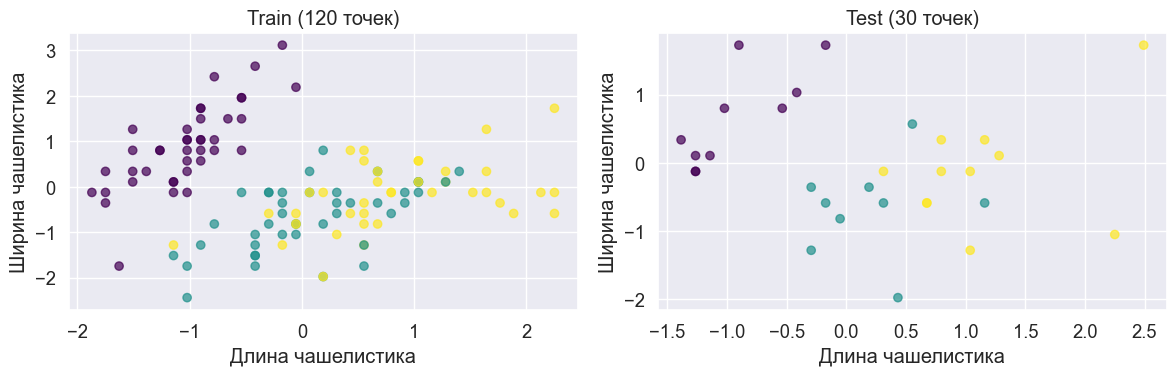

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Train
axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', alpha=0.7)
axes[0].set_title(f'Train ({len(X_train)} точек)')
axes[0].set_xlabel('Длина чашелистика')
axes[0].set_ylabel('Ширина чашелистика')

# Test
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', alpha=0.7)
axes[1].set_title(f'Test ({len(X_test)} точек)')
axes[1].set_xlabel('Длина чашелистика')
axes[1].set_ylabel('Ширина чашелистика')

plt.tight_layout()
plt.show()

In [62]:
y_pred = knn.predict(X_test)
accuracy_score(y_test, y_pred)

0.9666666666666667

In [61]:
models = {
    'K=3, euclidean, uniform': KNeighborsClassifier(n_neighbors=3, metric='euclidean', weights='uniform'),
    'K=5, euclidean, uniform': KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform'),
    'K=7, euclidean, uniform': KNeighborsClassifier(n_neighbors=7, metric='euclidean', weights='uniform'),
    'K=3, manhattan, distance': KNeighborsClassifier(n_neighbors=3, metric='manhattan', weights='distance'),
    'K=5, manhattan, distance': KNeighborsClassifier(n_neighbors=5, metric='manhattan', weights='distance'),
    'K=7, minkowski, distance': KNeighborsClassifier(n_neighbors=7, metric='minkowski', weights='distance'),
    'K=10, euclidean, distance': KNeighborsClassifier(n_neighbors=10, metric='euclidean', weights='distance'),
    'K=15, manhattan, uniform': KNeighborsClassifier(n_neighbors=15, metric='manhattan', weights='uniform'),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f'{name}: {acc:.3f}')

K=3, euclidean, uniform: 0.967
K=5, euclidean, uniform: 0.967
K=7, euclidean, uniform: 0.967
K=3, manhattan, distance: 0.967
K=5, manhattan, distance: 0.967
K=7, minkowski, distance: 0.967
K=10, euclidean, distance: 1.000
K=15, manhattan, uniform: 1.000


Сложно пока что-то сказать, потому что датасет достаточно простой и очень все зависит от random_state, поэтому я так понимаю сейчас это решится с кросс-валидацией

## Подбор гиперпараметров с кросс-валидацией

In [70]:
params = {
    'n_neighbors': [2, 3, 5, 7, 10, 15, 30],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid = GridSearchCV(KNeighborsClassifier(), params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print('Лучшие параметры:', grid.best_params_)
print('Лучшая точность (cv):', round(grid.best_score_, 3))
print('Точность на тесте:', round(accuracy_score(y_test, grid.predict(X_test)), 3))

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
Лучшая точность (cv): 0.967
Точность на тесте: 0.967


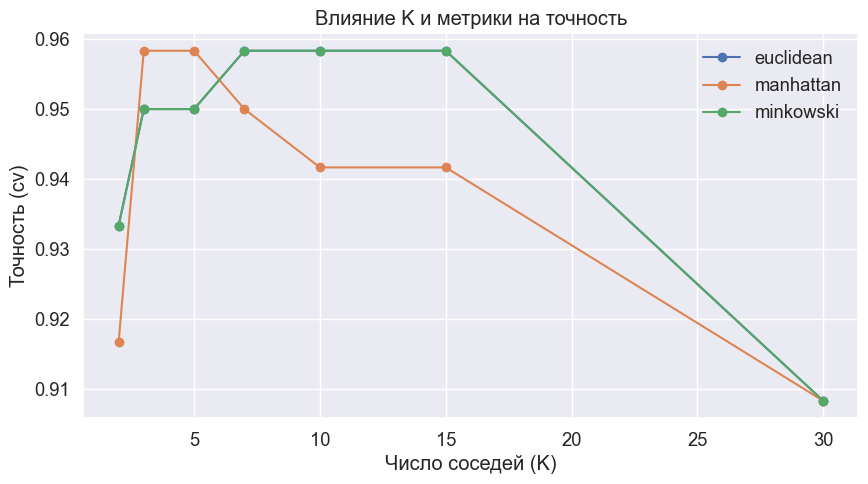

In [71]:
# Визуализация — влияние K на точность
results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(10, 5))
for metric in ['euclidean', 'manhattan', 'minkowski']:
    subset = results[
        (results['param_metric'] == metric) & 
        (results['param_weights'] == 'uniform')
    ]
    plt.plot(subset['param_n_neighbors'], subset['mean_test_score'], marker='o', label=metric)

plt.xlabel('Число соседей (K)')
plt.ylabel('Точность (cv)')
plt.title('Влияние K и метрики на точность')
plt.legend()
plt.grid(True)
plt.show()

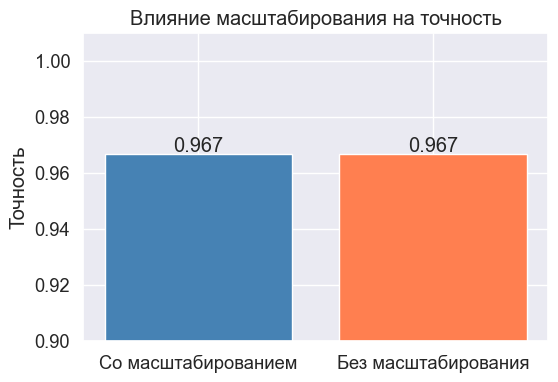

In [72]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=1)

grid_raw = GridSearchCV(KNeighborsClassifier(), params, cv=5, scoring='accuracy')
grid_raw.fit(X_train_raw, y_train_raw)

acc_scaled = accuracy_score(y_test, grid.predict(X_test))
acc_raw = accuracy_score(y_test_raw, grid_raw.predict(X_test_raw))

plt.figure(figsize=(6, 4))
plt.bar(['Со масштабированием', 'Без масштабирования'], [acc_scaled, acc_raw], 
        color=['steelblue', 'coral'])
plt.ylabel('Точность')
plt.title('Влияние масштабирования на точность')
plt.ylim(0.9, 1.01)
for i, v in enumerate([acc_scaled, acc_raw]):
    plt.text(i, v + 0.001, f'{v:.3f}', ha='center')
plt.show()

В нашем датасете не повлияло, т.к. изначально оно и так было в похожих диапазонах и были в см.

## Выводы

Попался достаточно простой датасет: пропусков не было и данные отмасштабированы.  
При разделении только на train/test точность очень зависит от random_state, даже сложно сказать сколько соседей надо и какая метрика лучше, поэтому использовал кросс-валидацию и уже с помощью нее увидел, настоющуюю точность (96.7%) на валидации и она совпала с тестом (что есть хорошо).  
Так же увидел влияние k на точность. С графика видно, что Евклидовая метрика и Минсковского являются одной ломаной и лучше всего нам подходит любая из этих метрик при k = 7. 